# Network Types: From Synthetic to Real-World Data (Part 2)

## Introduction

In Part 1 we simulated epidemics on three synthetic network types (random, small-world, preferential attachment). Here we extend that to more realistic structures:

- **Configuration model** — uses an empirical degree distribution (POLYMOD contact survey data)
- **Proportionate mixing** — samples degrees from a fitted negative binomial distribution
- **Edgelist network** — a real contact network loaded directly from a data file

We will fit the POLYMOD data, load the empirical network, and compare all network types using the same epidemic model (SIR, no hospitalization).

## Setup

We will use the same setup as in Part 1, running everything at once

In [1]:
cd(@__DIR__)

# Per-notebook output directories
const FIGURES_DIR = "figures/part2"
const DATA_DIR    = "data/part2"

mkpath(FIGURES_DIR)
mkpath(DATA_DIR)
mkpath("output")

using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

using Agents, Graphs, Random, Plots, DataFrames, CSV, CategoricalArrays,
      Statistics, StatsBase, StatsPlots, Distributions, Measures, Optim
using GraphIO.EdgeList

include("src/create_graph.jl")

@agent struct Person(GraphAgent)
    status::Symbol       = :S
    days_infected::Int   = 0
    contact_rate::Symbol = :high
end

include("src/initialize.jl")
include("src/agent_step.jl")

function model_step!(model::AgentBasedModel)
    model.susceptible_count = sum(model[i].status == :S for i in 1:nv(model.graph))
    model.infected_count    = sum(model[i].status == :I for i in 1:nv(model.graph))
    model.recovered_count   = sum(model[i].status == :R for i in 1:nv(model.graph))
end

  Activating project at `c:\Users\Leonard\julia-workspace\espidam-tutorial-2026`


model_step! (generic function with 1 method)

## Task 1: POLYMOD Data Exploration

To construct a configuration model network, we use a degree distribution read from a CSV file. This file must contain one integer degree per row, with the total number of rows matching the desired network population size. Each row specifies the degree (number of contacts) for a single node. In the folder `degs`, you can find several degree distributions for different countries. Feel free to use any of the provided files, for this you only have to change the file path to the country-specific file below, e.g. `CSV.read("degs/deg_dist_DE.csv")`

- **Configuration Model:**  
    Uses the degree distribution from `deg_dist_"COUNTRY".csv`, allowing the network to reflect real-world or empirically sampled contact patterns.

- **Proportionate Mixing Network:**  
    Generates the degree distribution by sampling from a negative binomial distribution, parameterized by the specified mean degree and dispersion.

### Working with Contact Data

To accurately model contact networks, we need to:

1. **Extract or create a realistic degree distribution** for our network nodes.
2. **Fit this distribution to a parametric form** (such as the negative binomial) to capture the heterogeneity in contact patterns.

In [2]:
# Read in deg_dist to use for the random_configuration_model
degrees = CSV.read("degs/deg_dist_DE.csv", DataFrame, header=false)

# Display the first 10 entries of the degree distribution
println("First 10 entries of the degree distribution:")
first(degrees, 10)

First 10 entries of the degree distribution:


Row,Column1
,Int64
1,7
2,6
3,16
4,9
5,5
6,3
7,5
8,3
9,5


## Fitting a Negative Binomial Distribution

The negative binomial distribution is often used to model heterogeneous contact patterns because:

1. It can capture the **overdispersion** typically seen in real contact data (variance > mean)
2. It has mathematical properties that make it suitable for analytical epidemic models
3. It can be parameterized in terms of a mean (μ) and dispersion parameter (θ)

### Parameters:
- **Mean (μ)**: Average number of contacts per person
- **Dispersion (θ)**: Controls the heterogeneity of contacts
  - Small values → high heterogeneity (some people have many more contacts than others)
  - Large values → more homogeneous (most people have similar numbers of contacts)

We'll now load our degree data and fit a negative binomial distribution using maximum likelihood estimation.

In [3]:
# Read in specific degree distribution data if wanted
degrees = CSV.read("degs/deg_dist_DE.csv", DataFrame, header=false)
data = degrees[!, :Column1]

# Display basic statistics
println("Degree Distribution Statistics:")
println("Number of samples: $(length(data))")
println("Mean: $(mean(data))")
println("Variance: $(var(data))")
println("Min: $(minimum(data)), Max: $(maximum(data))")

# Create a frequency table of the degrees
degree_counts = countmap(data)
sorted_degrees = sort(collect(keys(degree_counts)))
freq_table = DataFrame(
    Degree = sorted_degrees,
    Count = [degree_counts[d] for d in sorted_degrees],
    Frequency = [degree_counts[d]/length(data) for d in sorted_degrees]
)

# Display the first few rows of the frequency table
println("\nDegree frequency distribution (first 10 rows):")
first(freq_table, 10)

Degree Distribution Statistics:
Number of samples: 1000
Mean: 7.994
Variance: 40.94891291291291
Min: 1, Max: 58

Degree frequency distribution (first 10 rows):


Row,Degree,Count,Frequency
,Int64,Int64,Float64
1,1,38,0.038
2,2,66,0.066
3,3,85,0.085
4,4,93,0.093
5,5,124,0.124
6,6,106,0.106
7,7,76,0.076
8,8,73,0.073
9,9,58,0.058


### Code Explanation: Fitting a Negative Binomial Distribution via Maximum Likelihood

This code fits a negative binomial distribution to the observed degree data using maximum likelihood estimation (MLE):

1. **Negative Log-Likelihood Function**  
    - `neg_log_likelihood_mu_theta(params, data)`:  
      - Computes the negative log-likelihood for the negative binomial distribution, parameterized by mean (μ) and dispersion (θ).
      - Converts (μ, θ) to the standard negative binomial parameters (r, p) used in Julia.
      - Returns `Inf` if parameters are not valid (μ, θ > 0).

2. **Fitting Function**  
    - `fit_negative_binomial_mu_theta(data)`:  
      - Uses the `optimize` function from the Optim package to minimize the negative log-likelihood.
      - Starts with initial guesses for μ (sample mean) and θ (set to 1.0).
      - Uses box constraints to ensure parameters remain positive.

3. **Parameter Extraction and Conversion**  
    - After optimization, extracts the fitted mean (μ) and dispersion (θ).
    - Converts these to the (r, p) parameterization required by Julia's `NegativeBinomial` distribution:
      - \( r = θ \)
      - \( p = θ / (θ + μ) \)

4. **Output**  
    - Prints the fitted parameters in both (μ, θ) and (r, p) forms for use in further modeling and simulation.

In [4]:
# Maximum Likelihood Estimation for fitting negative binomial distribution
# Define the negative log-likelihood function in terms of μ and θ
function neg_log_likelihood_mu_theta(params, data)
    μ, θ = params      # μ is the mean, θ the dispersion of the negative binomial distribution
    if μ <= 0 || θ <= 0
        return Inf
    end
    p = θ / (θ + μ)
    r = θ
    return -sum(logpdf.(NegativeBinomial(r, p), data))
end

# Function to fit the negative binomial distribution
function fit_negative_binomial_mu_theta(data)
    μ0 = mean(data)  # Initialize with sample mean
    θ0 = 1.0         # Initialize with reasonable dispersion
    
    result = optimize(
        p -> neg_log_likelihood_mu_theta(p, data),
        [0.01, 0.01], [1000.0, 100.0],
        [μ0, θ0],
        Fminbox()
    )
    
    return Optim.minimizer(result)
end

# Perform the fitting
fitted_μ, fitted_θ = fit_negative_binomial_mu_theta(data)
println("Fitted parameters:")
println("Mean (μ): $fitted_μ")
println("Dispersion (θ): $fitted_θ")

# Convert to r and p parameters that Julia's NegativeBinomial uses
r̂ = fitted_θ
p̂ = fitted_θ / (fitted_θ + fitted_μ)
println("Equivalent NegativeBinomial(r,p) parameters:")
println("r: $r̂")
println("p: $p̂")

Fitted parameters:
Mean (μ): 7.994000000032767
Dispersion (θ): 2.9451252252479003
Equivalent NegativeBinomial(r,p) parameters:
r: 2.9451252252479003
p: 0.26922858680158646


## Visualizing the Fit

A good way to evaluate whether the negative binomial distribution is an appropriate model for our degree distribution is to visualize the fit. We'll:

1. Create a histogram of our observed degree data
2. Overlay the probability density function (PDF) of the fitted negative binomial distribution
3. Compare visually how well the fit captures the data distribution

This visualization helps us assess whether:
- The general shape of the distribution is captured
- The fit handles the tail of the distribution appropriately
- There are specific features of the data that aren't well represented

The fitted parameters (μ and θ) will be used later for creating a proportionate mixing network, which samples degrees from this fitted negative binomial distribution.

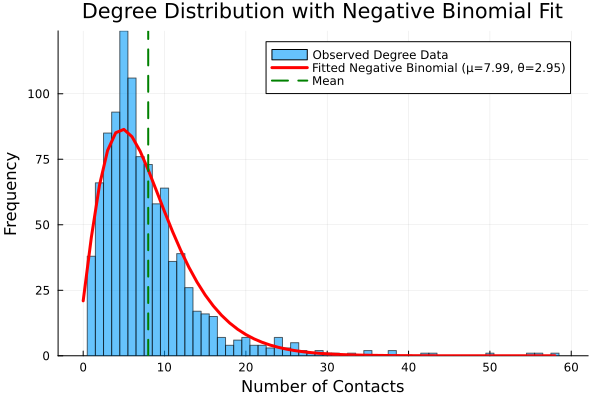

In [5]:
nb_fit = NegativeBinomial(r̂, p̂)

hist = fit(Histogram, data, nbins=maximum(data))
p = bar(hist.edges[1][1:end-1], hist.weights;
    label="Observed Degree Data",
    xlabel="Number of Contacts",
    ylabel="Frequency",
    bar_width=1.0,
    alpha=0.6,
    legend=:topright,
    title="Degree Distribution with Negative Binomial Fit")

x_vals = collect(0:maximum(data))
pdf_vals = pdf.(nb_fit, x_vals) .* length(data)

plot!(p, x_vals, pdf_vals;
    label="Fitted Negative Binomial (μ=$(round(fitted_μ, digits=2)), θ=$(round(fitted_θ, digits=2)))",
    linewidth=3, color=:red)
vline!([fitted_μ], label="Mean", linestyle=:dash, linewidth=2, color=:green)

display(p)
savefig(p, joinpath(FIGURES_DIR, "degree_distribution_fit.pdf"));

## Task 1: Summary

We've now completed the first task:
1. We examined the POLYMOD-like degree distribution data from `deg_dist.csv`
2. We calculated summary statistics to understand the central tendency and spread
3. We fitted a negative binomial distribution to capture the heterogeneity in contact patterns
4. We visualized the fit to assess how well the negative binomial model represents our data

The fitted parameters:
- **Mean (μ)**: Average number of contacts per person
- **Dispersion (θ)**: Determines the heterogeneity in contact counts

These parameters will now be used to:
1. Configure our epidemiological models
2. Generate synthetic contact networks with realistic properties using both the:
   - **Configuration model** (using the exact degree sequence)
   - **Proportionate mixing model** (sampling from the fitted distribution)

Next, we'll set up these network models and run epidemic simulations on them.

## Loading the Edgelist Network

In addition to synthetic networks, we can work with empirical contact networks stored as edgelists. An edgelist is simply a file where each row describes one edge as a pair of node IDs.

The file `degs/edgelist_n1000.csv` contains a synthetically generated contact network of 1,000 individuals (mean degree ≈ 10), stored as a CSV with two columns (`edge_1`, `edge_2`). We load it once here and reuse it throughout the rest of the notebook.

In [6]:
# Load the empirical contact network from a CSV edgelist (one edge per row)
edges_df = CSV.read("degs/edgelist_n1000.csv", DataFrame)

n_edgelist = max(maximum(edges_df[!, 1]), maximum(edges_df[!, 2]))
edgelist_graph = SimpleGraph(n_edgelist)
for row in eachrow(edges_df)
    add_edge!(edgelist_graph, row[1], row[2])
end

println("Edgelist network loaded:")
println("  Nodes: $(nv(edgelist_graph))")
println("  Edges: $(ne(edgelist_graph))")
println("  Mean degree: $(round(2 * ne(edgelist_graph) / nv(edgelist_graph), digits=2))")

Edgelist network loaded:
  Nodes: 1000
  Edges: 5018
  Mean degree: 10.04


## Model Setup

Now let's set up the model for our investigation. As a reminder, in the initialization function, we can configure the following parameters:

### Key Parameters:

- **Network Type** (`network_type`): The structure of the network
- **Infection Seed** (`patient_zero`): Initial location of infection introduction
- **High-Contact Proportion** (`fraction_high_contact`): Fraction of population with high contact rate
- **Mean Degree** (`mean_degree`): Average connections per node

### Available Network Types:

| Type | Description |
|------|-------------|
| **Random** (`:random`) (Part 1) | Equal probability of connection between any nodes |
| **Small-World** (`:smallworld`) (Part 1) | High clustering with short average path lengths |
| **Preferential Attachment** (`:preferential`) (Part 1) | Scale-free networks with highly-connected hubs |
| **Configuration Model** (`:configuration`) | Specified degree distribution from empirical data |
| **Proportionate Mixing** (`:proportionate`) | Degree distribution sampled from a fitted negative binomial |
| **Edgelist** (`:edgelist`) | Synthetic edgelist generated from real-world data |

</br>

> **Note:** The next five cells all use the model initialized here.

In [7]:
include("src/initialize.jl")
# Initialize the model with the chosen parameters
# Using the pre-loaded edgelist graph via custom_graph; switch network_type for other types
model = initialize(; network_type=:edgelist, custom_graph=edgelist_graph,
                   patient_zero=:maxdegree, use_hospitalization=false)

StandardABM with 1000 agents of type Person
 agents container: Dict
 space: GraphSpace with 1000 positions and 5018 edges
 scheduler: fastest
 properties: days_to_recovered, trans_prob, restricts_contact, mean_degree, use_behavior_adoption, use_hospitalization, contact_reduction, susceptible_count, low_risk_factor, infected_count, recovered_count, days_to_hospital_recovery, graph, dispersion, hospitalization_day, n_nodes, high_contact, hospitalization_prob, fraction_high_contact, behavior_alpha, behavior_beta, patient_zero, behavior_max_prob, hospitalized_count, network_type

## Network Analysis

This is based upon the initialized model above. The constructed network can be analyzed using our `analyze_graph` function, which returns a comprehensive set of network metrics:

### Calculated Metrics:

| **Category**            | **Metrics**                                                                 |
|-------------------------|-----------------------------------------------------------------------------|
| **Basic properties**    | Density, Mean degree, Clustering coefficient, Assortativity                 |
| **Component analysis**  | Number of connected components, Size distribution of components              |
| **Centrality measures** | Degree centrality, Betweenness centrality, Closeness centrality, Eigenvector centrality |
| **Structural properties** | Degree distribution, Maximal cliques, Network diameter                    |

Results are organized in a dictionary with easily accessible components for further analysis and visualization.

In [8]:
include("src/analyze_graph.jl")

graph_analysis = analyze_graph(model.graph)
analysis_display = print_graph_analysis(graph_analysis)

display("Graph Summary Metrics")
display(analysis_display.summary)
display("Centrality Measures Statistics")
display(analysis_display.centrality)
display("Component Size Summary")
display(analysis_display.component_summary)

CSV.write(joinpath(DATA_DIR, "centrality_$(model.network_type)_mdeg_$(model.mean_degree).csv"), graph_analysis["centrality"])
CSV.write(joinpath(DATA_DIR, "graph_summary_$(model.network_type)_mdeg_$(model.mean_degree).csv"), graph_analysis["summary"]);

"Graph Summary Metrics"

Row,metric,value
,String,Float64
1,Mean Degree,10.036
2,Density,0.010046
3,Clustering Coefficient,0.444873
4,Assortativity,0.0636964
5,Diameter,17.0
6,Number of Connected Components,1.0
7,Max Component Length,1000.0


"Centrality Measures Statistics"

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,degree_centrality,0.010046,0.003003,0.00900901,0.034034,0,Float64
2,betweenness_centrality,0.00625154,0.0,0.000309379,0.41501,0,Float64
3,closeness_centrality,0.142533,0.0885403,0.142156,0.228343,0,Float64
4,eigenvector_centrality,0.0120622,8.70454e-9,0.0018,0.340823,0,Float64


"Component Size Summary"

Row,component_size,count
,Int64,Int64
1,1000,1


## Network Visualization and Analysis

This is also based upon the initialized model above. We can use the results from our network analysis to create visualizations that help us understand the network structure. We'll examine:

1. **Degree distribution** - The frequency of nodes with different numbers of connections
2. **Centrality measures** - How these relate to epidemic dynamics

These visualizations provide insights into network properties that influence disease spread.

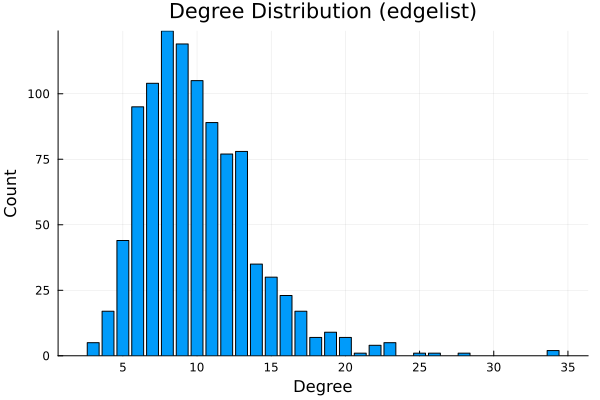

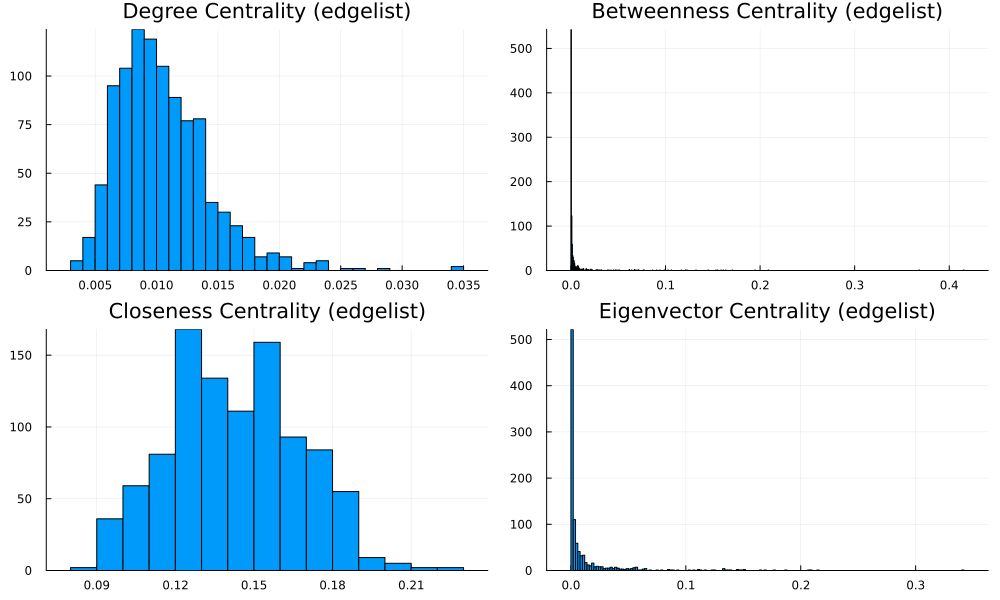

In [9]:
include("src/plotting.jl")

plotdegdist = plot_degree_distribution(graph_analysis["degree_distribution"]; network_type=model.network_type)
display(plotdegdist)
savefig(plotdegdist, joinpath(FIGURES_DIR, "plotdegdist_$(model.network_type)_mdeg_$(model.mean_degree).pdf"))

p1 = histogram(graph_analysis["centrality"].degree_centrality,     title="Degree Centrality ($(model.network_type))",     legend=false)
p2 = histogram(graph_analysis["centrality"].betweenness_centrality, title="Betweenness Centrality ($(model.network_type))", legend=false)
p3 = histogram(graph_analysis["centrality"].closeness_centrality,   title="Closeness Centrality ($(model.network_type))",   legend=false)
p4 = histogram(graph_analysis["centrality"].eigenvector_centrality, title="Eigenvector Centrality ($(model.network_type))", legend=false)

centrality_plot = plot(p1, p2, p3, p4, layout=(2,2), size=(1000, 600))
display(centrality_plot)
savefig(centrality_plot, joinpath(FIGURES_DIR, "centrality_$(model.network_type)_mdeg_$(model.mean_degree).pdf"));

## Epidemic Dynamics

This is based upon the initialized model above. To simulate the SIR dynamics, we use the `run!` function with the following parameters:

- **Model**: Our initialized network model
- **Duration**: Number of days to simulate
- **Data collection**:
  - `adata`: Agent-level data (infection status)
  - `mdata`: Model-level data (counts of S, I, R agents)

The simulation updates each agent's status based on interactions with their neighbors, following the rules defined in our `agent_step.jl` file.

Results are stored in DataFrames `adf` (agent data) and `mdf` (model data) for further analysis.

In [10]:
# specify "adata" (agent data to collect) and "mdata" (model data to collect)
adata = [:status]
mdata = [:susceptible_count, :infected_count, :recovered_count]

adf, mdf = run!(model, 100; adata, mdata);

## Epidemic Trajectory Visualization

Again, we use the model initialized above. The plot below illustrates the epidemic trajectories over time:

- **Susceptible**: Decreases as the infection spreads.
- **Infected**: Rises and falls as individuals become infected and then recover.
- **Recovered**: Increases as infected individuals recover.

Saved plot filename includes:
- *Network type: (e.g., `random`, `smallworld`, etc.)*
- *Mean degree*
- *Network size:* (number of nodes)
- *Dispersion parameter*
- *Patient zero selection method*
- *Risk parameters*
- *Transmission probability*

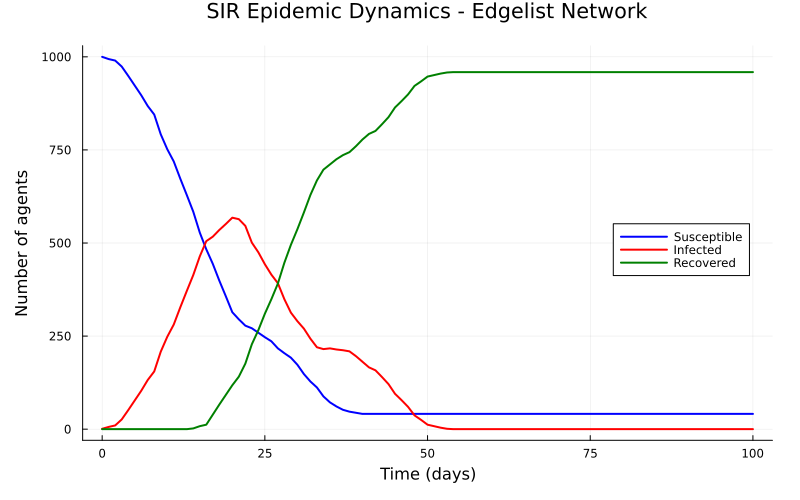

In [11]:
plotdynamics = plot_epidemic_trajectories(mdf, model.network_type)
display(plotdynamics)
savefig(plotdynamics, joinpath(FIGURES_DIR, "plotdynamics_$(model.network_type)_mdeg_$(model.mean_degree)_nn_$(model.n_nodes)_pat0_$(model.patient_zero)_trans_$(model.trans_prob).pdf"));

## Single Run Visualization

Let's run a single simulation and examine both:
1. The epidemic dynamics plot (showing S, I, R counts over time)
2. The degree distribution plot (showing network connectivity patterns)

The `plot_single_run` function returns both individual plots and a combined visualization, making it easy to analyze relationships between network structure and disease spread. The combined figure is saved in the `figures` directory.

This function (as well as the ones being used later) can also take several additional parameters, which up to now have all been used with their default values. To facilitate further exploration, here is a short description of all relevant parameters.

- `high_contact::Symbol`: How high-contact individuals are distributed. Possible values are `:random`, `:maxdegree`, `:maxbetweenness`, and `:maxeigenvector`. Default is `:random`.
- `fraction_high_contact::Float64`: The fraction of high-contact individuals in the population. Default is 1.0.
- `low_risk_factor::Float64`: The factor by which low-contact individuals' transmission probability is multiplied. Must be between 0 and 1. Default is 1.0.
- `trans_prob::Float64`: The transmission probability. Default is 0.1.

</br>

> **Note:** Starting from here, a new model is initialized automatically using the provided parameters.

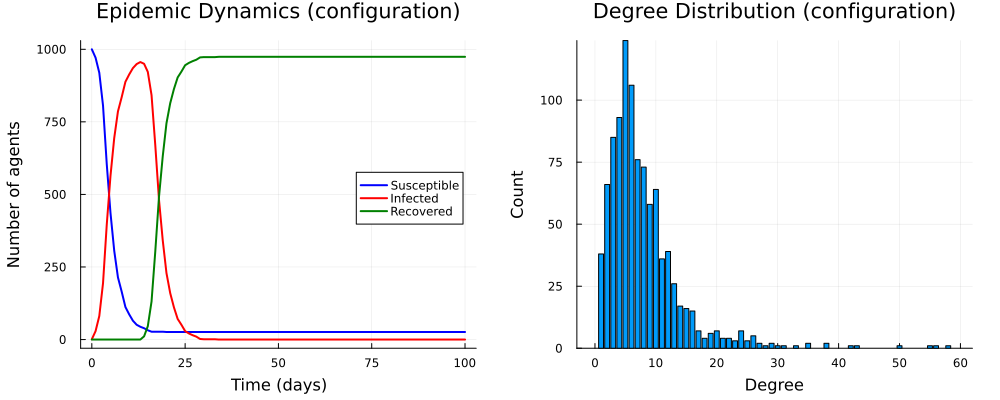

In [12]:
include("src/plotting.jl")

dynamics_plot, degdist_plot, combined_plot = plot_single_run(;
    network_type=:configuration, patient_zero=:maxdegree,
    degrees=degrees[!, 1], r̂=r̂, p̂=p̂, use_hospitalization=false, figures_dir=FIGURES_DIR)

display(combined_plot)

## Multiple Run Analysis

The `run_and_plot_comparison` function generates three key epidemic metrics across multiple simulation runs (100 in this case):

1. **Epidemic Duration**: Time from first to last infection
   - *Longer durations* may indicate slower but persistent spread

2. **Maximum Infected**: Peak number of simultaneous infections
   - *Higher peaks* suggest rapid spread that could overwhelm healthcare systems

3. **Susceptible Fraction Remaining**: Population proportion that escapes infection
   - *Lower values* indicate more complete spread through the population

These metrics help quantify how network structure influences epidemic outcomes, with results automatically saved to the figures directory.

> **Note:** Outliers are not shown in the boxplots.

Running simulations for configuration network...


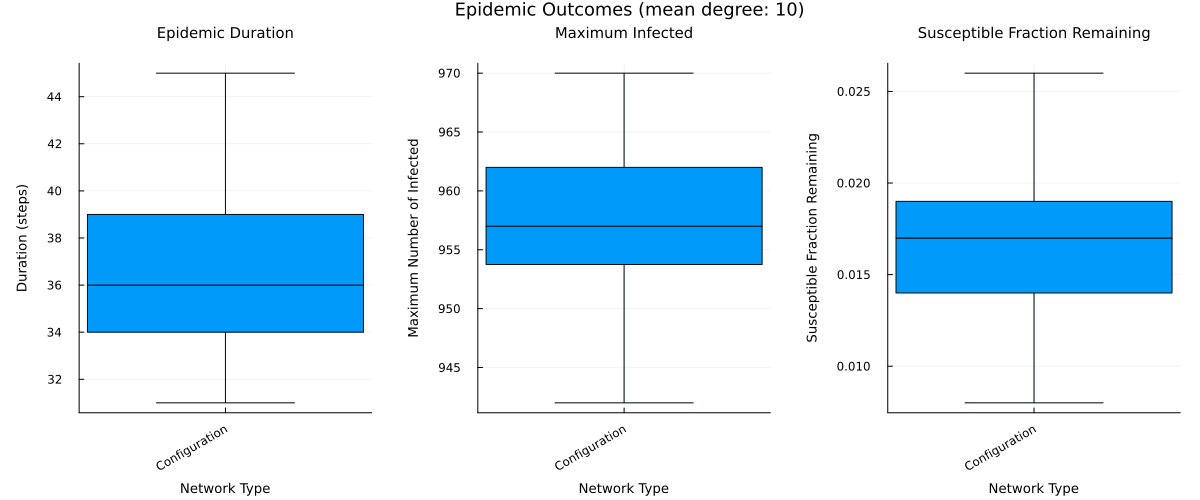

In [13]:
include.(["src/create_graph.jl", "src/initialize.jl", "src/agent_step.jl", "src/run_simulations.jl"])

combined_comparison = run_and_plot_comparison(
    network_types=[:configuration],
    mean_degree=10,
    patient_zero=:maxdegree,
    degrees=degrees[!, 1], r̂=r̂, p̂=p̂,
    use_hospitalization=false,
    figures_dir=FIGURES_DIR,
);

display(combined_comparison)

## Comparing Different Network Types

To understand how network structure influences epidemic dynamics, we can directly compare multiple network types side by side. By passing a vector of network types (e.g., `[:random, :preferential, :smallworld]`) to the simulation and plotting functions, we generate results for each network under identical conditions.

This approach allows us to:

- **Visualize epidemic trajectories** for each network type on the same axes
- **Compare key epidemic metrics** (such as duration, peak prevalence, and final size) across network structures
- **Identify structural features** (like clustering or degree distribution) that impact disease spread

Such comparisons highlight how properties unique to each network—such as the presence of hubs in preferential attachment networks or high clustering in small-world networks—can accelerate or slow down epidemic spread. This insight is crucial for designing effective intervention strategies tailored to specific contact patterns.

Running simulations for random network...
Running simulations for configuration network...
Running simulations for proportionate network...
Running simulations for edgelist network...


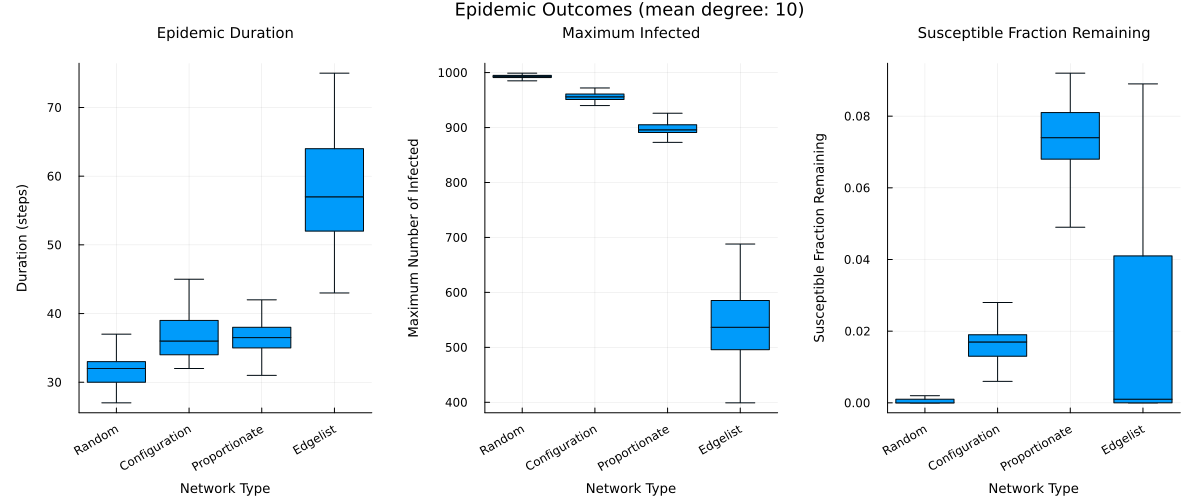

In [14]:
include("src/run_simulations.jl")
include("src/plotting.jl")

combined_comparison = run_and_plot_comparison(
    network_types=[:random, :configuration, :proportionate, :edgelist],
    mean_degree=10,
    patient_zero=:maxdegree,
    degrees=degrees[!, 1], r̂=r̂, p̂=p̂,
    use_hospitalization=false,
    figures_dir=FIGURES_DIR,
);

display(combined_comparison)

## Network Metrics Comparison

Different network topologies possess distinct structural properties that influence disease transmission dynamics. We can visualize these differences using a chart that compares key metrics across network types:

### Structural Metrics:
- **Density**: Ratio of actual connections to all possible connections
- **Clustering coefficient**: Tendency of nodes to form tightly-knit groups
- **Assortativity**: Correlation between degrees of connected nodes
  - *Positive*: Similar-degree nodes connect (homophily)
  - *Negative*: Dissimilar-degree nodes connect (heterophily)

### Centrality Metrics:
- **Degree centrality**: Number of direct connections
- **Betweenness centrality**: Frequency of node appearing on shortest paths
- **Closeness centrality**: Average distance to all other nodes
- **Eigenvector centrality**: Connection to other important nodes

Our visualization makes it easy to compare metrics across different network types at a glance.

Analyzing preferential network...
Analyzing configuration network...
Analyzing proportionate network...
Analyzing edgelist network...


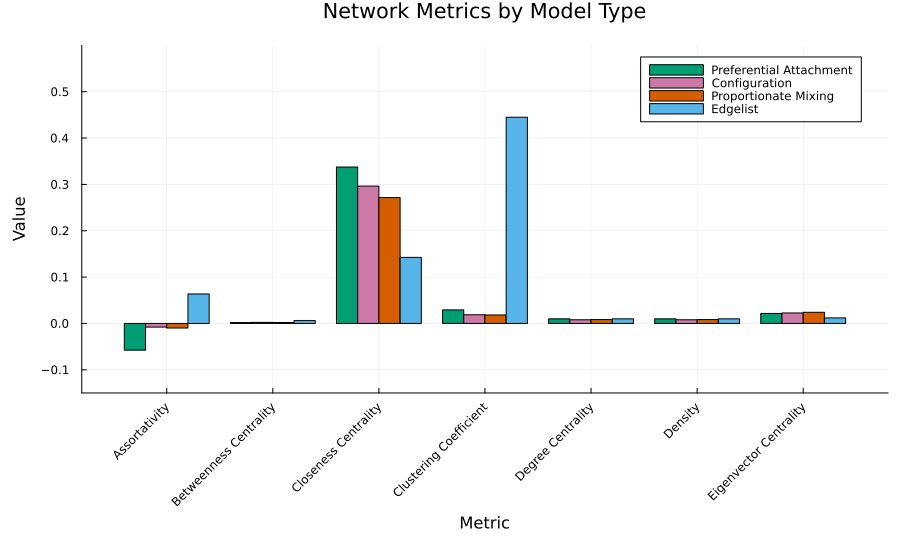

In [15]:
include("src/plotting.jl")

metrics_plot = plot_network_metrics_comparison(
    network_types=[:preferential, :configuration, :proportionate, :edgelist],
    mean_degree=10,
    degrees=degrees[!, 1], r̂=r̂, p̂=p̂,
    figures_dir=FIGURES_DIR,
)

display(metrics_plot)

## Centrality Distribution Comparison

The boxplots below show the distribution of centrality measures across different network types:

### Centrality Measures:
- **Degree centrality**: Proportion of nodes directly connected to a node
- **Betweenness centrality**: Fraction of shortest paths passing through a node
- **Closeness centrality**: Inverse of the sum of shortest distances to all other nodes
- **Eigenvector centrality**: Measures influence based on connections to other influential nodes

The visualization highlights:
1. **Preferential attachment networks** show the highest variability in centrality measures, particularly in closeness centrality
2. **Small-world networks** have moderate closeness centrality values with less variation
3. **Random networks** generally show the lowest variability across centrality measures

These differences in centrality distributions directly impact how diseases spread through networks. Nodes with high centrality often serve as key transmission points in epidemics.

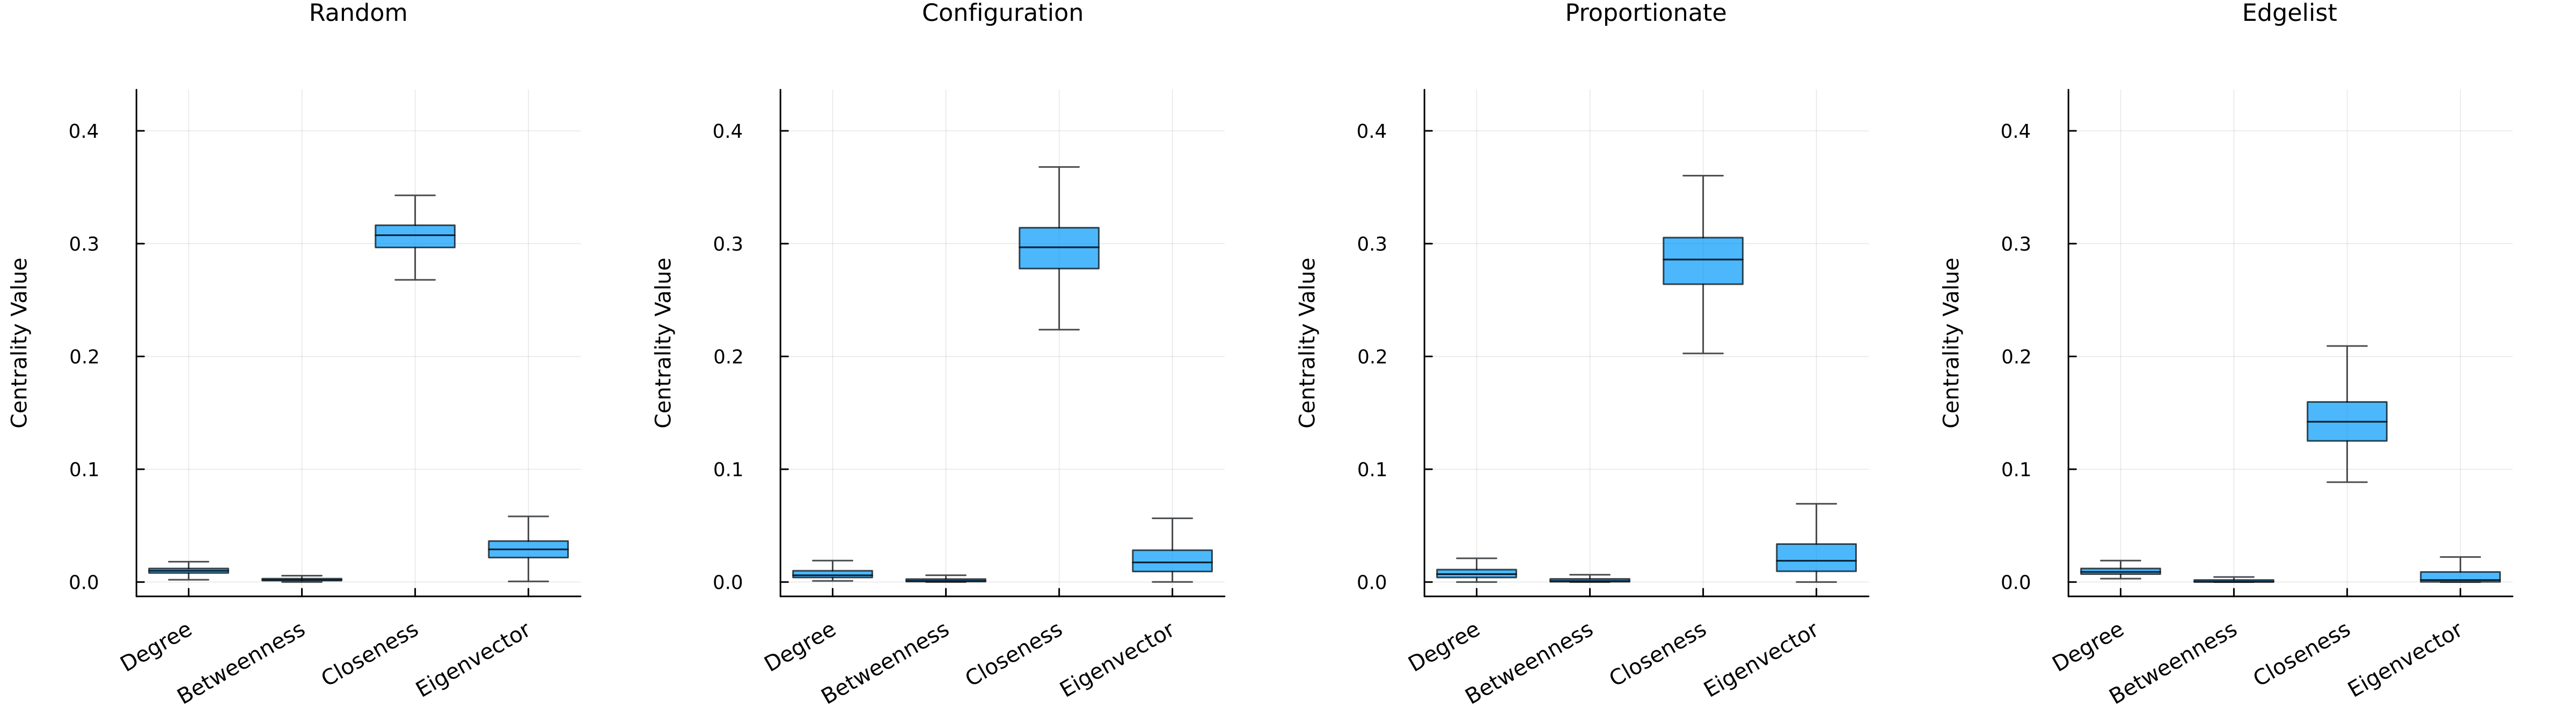

In [16]:
include("src/plotting.jl")

centrality_comparison = plot_centrality_comparison(;
    network_types=[:random, :configuration, :proportionate, :edgelist],
    mean_degree=10,
    link_axes=true,
    degrees=degrees[!, 1], r̂=r̂, p̂=p̂,
    figures_dir=FIGURES_DIR,
)
display(centrality_comparison)